# 01 - Funnel Analysis Validation

**Purpose:** Cross-validate SQL-derived funnel metrics and revenue leakage calculations in Python.

---

## 1️⃣ Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for clean visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')
pd.set_option('display.float_format', '{:,.2f}'.format)

## 2️⃣ Data Loading

In [2]:
def load_session_funnel(path: str) -> pd.DataFrame:
    """
    Load session-level funnel data exported from BigQuery.
    Performs basic type validation and cleanup.
    """
    df = pd.read_csv(path)
    
    # Convert funnel flags to int
    flag_cols = ['viewed_product', 'added_to_cart', 'checkout_started', 'purchased']
    for col in flag_cols:
        df[col] = df[col].astype(int)
    
    # Convert revenue NaN → 0 (for analysis only)
    df['revenue'] = df['revenue'].fillna(0)
    
    return df

In [3]:
# Load the data
DATA_PATH = '../Outputs/query_results/session_funnel_sample.csv'
df = load_session_funnel(DATA_PATH)

print(f"Loaded {len(df):,} sessions")
df.head()

Loaded 83,553 sessions


,session_id,user_id,device_type,traffic_source,country,viewed_product,added_to_cart,checkout_started,purchased,revenue
0,45337213900853054591478134261,4533721390085305459,desktop,(direct),Colombia,1,0,0,0,0.00
1,95332140470133129751478101934,9533214047013312975,desktop,(direct),Israel,1,0,0,0,0.00
2,11012865914099934431478121835,1101286591409993443,desktop,(direct),United States,1,0,0,0,0.00
3,17344883748372213461478089449,1734488374837221346,desktop,(direct),Canada,1,1,0,0,0.00
4,98540734772901917461478153398,9854073477290191746,tablet,(direct),Canada,1,0,0,0,0.00


In [4]:
# Data hygiene check
print("Column dtypes:")
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())

Column dtypes:
session_id           object
user_id              uint64
device_type          object
traffic_source       object
country              object
viewed_product        int64
added_to_cart         int64
checkout_started      int64
purchased             int64
revenue             float64
dtype: object

Null values:
session_id          0
user_id             0
device_type         0
traffic_source      0
country             0
viewed_product      0
added_to_cart       0
checkout_started    0
purchased           0
revenue             0
dtype: int64


## 3️⃣ Funnel Metrics Validation

In [5]:
def compute_funnel_metrics(df: pd.DataFrame) -> dict:
    """
    Compute funnel volumes and conversion rates.
    Used to validate SQL-derived metrics.
    """
    total_sessions = len(df)
    
    # Sessions at each funnel stage
    viewed = df['viewed_product'].sum()
    carted = df['added_to_cart'].sum()
    checkout = df['checkout_started'].sum()
    purchased = df['purchased'].sum()
    
    # Conversion rates (stage-to-stage)
    view_to_cart = (carted / viewed * 100) if viewed > 0 else 0
    cart_to_checkout = (checkout / carted * 100) if carted > 0 else 0
    checkout_to_purchase = (purchased / checkout * 100) if checkout > 0 else 0
    overall_conversion = (purchased / viewed * 100) if viewed > 0 else 0
    
    return {
        'total_sessions': total_sessions,
        'viewed_product': viewed,
        'added_to_cart': carted,
        'checkout_started': checkout,
        'purchased': purchased,
        'view_to_cart_rate': view_to_cart,
        'cart_to_checkout_rate': cart_to_checkout,
        'checkout_to_purchase_rate': checkout_to_purchase,
        'overall_conversion_rate': overall_conversion
    }

In [6]:
metrics = compute_funnel_metrics(df)

print("=" * 50)
print("FUNNEL METRICS VALIDATION")
print("=" * 50)
print(f"\nTotal Sessions: {metrics['total_sessions']:,}")
print(f"\nFunnel Volumes:")
print(f"  Viewed Product:    {metrics['viewed_product']:,}")
print(f"  Added to Cart:     {metrics['added_to_cart']:,}")
print(f"  Checkout Started:  {metrics['checkout_started']:,}")
print(f"  Purchased:         {metrics['purchased']:,}")
print(f"\nConversion Rates:")
print(f"  View → Cart:       {metrics['view_to_cart_rate']:.2f}%")
print(f"  Cart → Checkout:   {metrics['cart_to_checkout_rate']:.2f}%")
print(f"  Checkout → Purchase: {metrics['checkout_to_purchase_rate']:.2f}%")
print(f"  Overall Conversion:  {metrics['overall_conversion_rate']:.2f}%")
print("=" * 50)

FUNNEL METRICS VALIDATION

Total Sessions: 83,553

Funnel Volumes:
  Viewed Product:    78,311
  Added to Cart:     31,553
  Checkout Started:  14,210
  Purchased:         7,287

Conversion Rates:
  View → Cart:       40.29%
  Cart → Checkout:   45.04%
  Checkout → Purchase: 51.28%
  Overall Conversion:  9.31%


## 4️⃣ Revenue Metrics

In [7]:
def compute_revenue_metrics(df: pd.DataFrame) -> dict:
    """
    Compute revenue per session and average revenue per purchase.
    """
    total_revenue = df['revenue'].sum()
    total_sessions = len(df)
    total_purchases = df['purchased'].sum()
    
    revenue_per_session = total_revenue / total_sessions if total_sessions > 0 else 0
    aov = total_revenue / total_purchases if total_purchases > 0 else 0  # Average Order Value
    
    return {
        'total_revenue': total_revenue,
        'total_sessions': total_sessions,
        'total_purchases': total_purchases,
        'revenue_per_session': revenue_per_session,
        'average_order_value': aov
    }

In [8]:
rev_metrics = compute_revenue_metrics(df)

print("=" * 50)
print("REVENUE METRICS")
print("=" * 50)
print(f"\nTotal Revenue:        ${rev_metrics['total_revenue']:,.2f}")
print(f"Total Sessions:       {rev_metrics['total_sessions']:,}")
print(f"Total Purchases:      {rev_metrics['total_purchases']:,}")
print(f"\nRevenue Per Session:  ${rev_metrics['revenue_per_session']:.2f}")
print(f"Average Order Value:  ${rev_metrics['average_order_value']:.2f}")
print("=" * 50)

REVENUE METRICS

Total Revenue:        $1,161,837.76
Total Sessions:       83,553
Total Purchases:      7,287

Revenue Per Session:  $13.91
Average Order Value:  $159.44


## 5️⃣ Revenue Leakage by Funnel Stage

In [9]:
def compute_revenue_leakage_by_stage(df: pd.DataFrame) -> pd.DataFrame:
    """
    Estimate revenue leakage at each funnel stage using
    average revenue per purchase.
    """
    # Compute AOV for estimation
    total_revenue = df['revenue'].sum()
    total_purchases = df['purchased'].sum()
    aov = total_revenue / total_purchases if total_purchases > 0 else 0
    
    # Funnel volumes
    viewed = df['viewed_product'].sum()
    carted = df['added_to_cart'].sum()
    checkout = df['checkout_started'].sum()
    purchased = df['purchased'].sum()
    
    # Drop-offs at each stage
    drop_view_to_cart = viewed - carted
    drop_cart_to_checkout = carted - checkout
    drop_checkout_to_purchase = checkout - purchased
    
    # Estimated revenue leakage = drops × AOV
    leakage_data = [
        {
            'funnel_stage': 'View → Cart',
            'sessions_entered': viewed,
            'sessions_progressed': carted,
            'drop_sessions': drop_view_to_cart,
            'estimated_revenue_leakage': drop_view_to_cart * aov
        },
        {
            'funnel_stage': 'Cart → Checkout',
            'sessions_entered': carted,
            'sessions_progressed': checkout,
            'drop_sessions': drop_cart_to_checkout,
            'estimated_revenue_leakage': drop_cart_to_checkout * aov
        },
        {
            'funnel_stage': 'Checkout → Purchase',
            'sessions_entered': checkout,
            'sessions_progressed': purchased,
            'drop_sessions': drop_checkout_to_purchase,
            'estimated_revenue_leakage': drop_checkout_to_purchase * aov
        }
    ]
    
    return pd.DataFrame(leakage_data)

In [10]:
leakage_df = compute_revenue_leakage_by_stage(df)

print("=" * 70)
print("REVENUE LEAKAGE BY FUNNEL STAGE")
print("=" * 70)
display(leakage_df.style.format({
    'sessions_entered': '{:,.0f}',
    'sessions_progressed': '{:,.0f}',
    'drop_sessions': '{:,.0f}',
    'estimated_revenue_leakage': '${:,.2f}'
}))

total_leakage = leakage_df['estimated_revenue_leakage'].sum()
print(f"\nTotal Estimated Revenue Leakage: ${total_leakage:,.2f}")

REVENUE LEAKAGE BY FUNNEL STAGE


,funnel_stage,sessions_entered,sessions_progressed,drop_sessions,estimated_revenue_leakage
0,View → Cart,"78,311","31,553","46,758","$7,455,085.77"
1,Cart → Checkout,"31,553","14,210","17,343","$2,765,164.30"
2,Checkout → Purchase,"14,210","7,287","6,923","$1,103,801.68"



Total Estimated Revenue Leakage: $11,324,051.75


## 6️⃣ Segmentation Function (Reusable)

In [11]:
def compute_segment_leakage(df: pd.DataFrame, segment_col: str) -> pd.DataFrame:
    """
    Compute View → Cart revenue leakage for a given segment
    (device_type, traffic_source, country).
    """
    # Compute AOV for estimation
    total_revenue = df['revenue'].sum()
    total_purchases = df['purchased'].sum()
    aov = total_revenue / total_purchases if total_purchases > 0 else 0
    
    # Aggregate by segment
    segment_agg = df.groupby(segment_col).agg({
        'viewed_product': 'sum',
        'added_to_cart': 'sum',
        'checkout_started': 'sum',
        'purchased': 'sum',
        'revenue': 'sum'
    }).reset_index()
    
    # Calculate drop-offs and leakage
    segment_agg['view_to_cart_drops'] = segment_agg['viewed_product'] - segment_agg['added_to_cart']
    segment_agg['cart_to_checkout_drops'] = segment_agg['added_to_cart'] - segment_agg['checkout_started']
    segment_agg['checkout_to_purchase_drops'] = segment_agg['checkout_started'] - segment_agg['purchased']
    
    # Calculate conversion rates
    segment_agg['view_to_cart_rate'] = (
        segment_agg['added_to_cart'] / segment_agg['viewed_product'] * 100
    ).fillna(0)
    
    # Estimated revenue leakage (view → cart only as primary leakage point)
    segment_agg['estimated_leakage'] = segment_agg['view_to_cart_drops'] * aov
    
    # Sort by leakage descending
    segment_agg = segment_agg.sort_values('estimated_leakage', ascending=False)
    
    return segment_agg

In [12]:
# Device Type Leakage
device_leakage = compute_segment_leakage(df, 'device_type')

print("=" * 70)
print("REVENUE LEAKAGE BY DEVICE TYPE")
print("=" * 70)
display(device_leakage[[
    'device_type', 'viewed_product', 'added_to_cart', 
    'view_to_cart_rate', 'view_to_cart_drops', 'estimated_leakage'
]].style.format({
    'viewed_product': '{:,.0f}',
    'added_to_cart': '{:,.0f}',
    'view_to_cart_rate': '{:.2f}%',
    'view_to_cart_drops': '{:,.0f}',
    'estimated_leakage': '${:,.2f}'
}))

REVENUE LEAKAGE BY DEVICE TYPE


,device_type,viewed_product,added_to_cart,view_to_cart_rate,view_to_cart_drops,estimated_leakage
0,desktop,"59,673","25,505",42.74%,"34,168","$5,447,738.79"
1,mobile,"16,349","5,251",32.12%,"11,098","$1,769,462.81"
2,tablet,"2,289",797,34.82%,"1,492","$237,884.17"


In [13]:
# Traffic Source Leakage
traffic_leakage = compute_segment_leakage(df, 'traffic_source')

print("=" * 70)
print("REVENUE LEAKAGE BY TRAFFIC SOURCE")
print("=" * 70)
display(traffic_leakage[[
    'traffic_source', 'viewed_product', 'added_to_cart', 
    'view_to_cart_rate', 'view_to_cart_drops', 'estimated_leakage'
]].head(10).style.format({
    'viewed_product': '{:,.0f}',
    'added_to_cart': '{:,.0f}',
    'view_to_cart_rate': '{:.2f}%',
    'view_to_cart_drops': '{:,.0f}',
    'estimated_leakage': '${:,.2f}'
}))

REVENUE LEAKAGE BY TRAFFIC SOURCE


,traffic_source,viewed_product,added_to_cart,view_to_cart_rate,view_to_cart_drops,estimated_leakage
0,(direct),"44,830","19,347",43.16%,"25,483","$4,063,004.20"
36,google,"25,694","9,200",35.81%,"16,494","$2,629,799.92"
125,youtube.com,"2,195",648,29.52%,"1,547","$246,653.36"
2,Partners,"1,172",510,43.52%,662,"$105,549.14"
25,dfa,849,301,35.45%,548,"$87,373.01"
5,analytics.google.com,654,317,48.47%,337,"$53,731.21"
43,google.com,366,116,31.69%,250,"$39,859.95"
112,sites.google.com,297,110,37.04%,187,"$29,815.24"
111,siliconvalley.about.com,185,32,17.30%,153,"$24,394.29"
101,qiita.com,168,47,27.98%,121,"$19,292.21"


In [14]:
# Country Leakage (Top 10)
country_leakage = compute_segment_leakage(df, 'country')

print("=" * 70)
print("REVENUE LEAKAGE BY COUNTRY (Top 10)")
print("=" * 70)
display(country_leakage[[
    'country', 'viewed_product', 'added_to_cart', 
    'view_to_cart_rate', 'view_to_cart_drops', 'estimated_leakage'
]].head(10).style.format({
    'viewed_product': '{:,.0f}',
    'added_to_cart': '{:,.0f}',
    'view_to_cart_rate': '{:.2f}%',
    'view_to_cart_drops': '{:,.0f}',
    'estimated_leakage': '${:,.2f}'
}))

REVENUE LEAKAGE BY COUNTRY (Top 10)


,country,viewed_product,added_to_cart,view_to_cart_rate,view_to_cart_drops,estimated_leakage
170,United States,"50,489","21,296",42.18%,"29,193","$4,654,525.83"
28,Canada,"3,318","1,457",43.91%,"1,861","$296,717.45"
71,India,"3,125","1,302",41.66%,"1,823","$290,658.74"
169,United Kingdom,"1,997",609,30.50%,"1,388","$221,302.43"
79,Japan,"1,289",448,34.76%,841,"$134,088.86"
55,Germany,"1,095",366,33.42%,729,"$116,231.61"
51,France,"1,020",360,35.29%,660,"$105,230.26"
8,Australia,970,369,38.04%,601,"$95,823.31"
154,Taiwan,872,319,36.58%,553,"$88,170.20"
77,Italy,644,196,30.43%,448,"$71,429.03"


## 7️⃣ Visualization (Light, Clean)

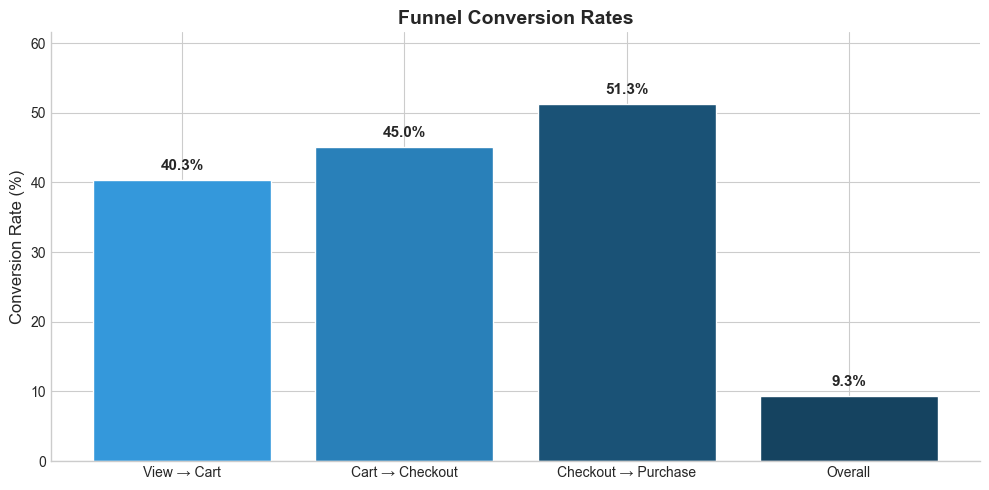

In [15]:
# Plot 1: Funnel Conversion Rates
fig, ax = plt.subplots(figsize=(10, 5))

stages = ['View → Cart', 'Cart → Checkout', 'Checkout → Purchase', 'Overall']
rates = [
    metrics['view_to_cart_rate'],
    metrics['cart_to_checkout_rate'],
    metrics['checkout_to_purchase_rate'],
    metrics['overall_conversion_rate']
]

bars = ax.bar(stages, rates, color=['#3498db', '#2980b9', '#1a5276', '#154360'], edgecolor='white')

# Add value labels
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Conversion Rate (%)', fontsize=12)
ax.set_title('Funnel Conversion Rates', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

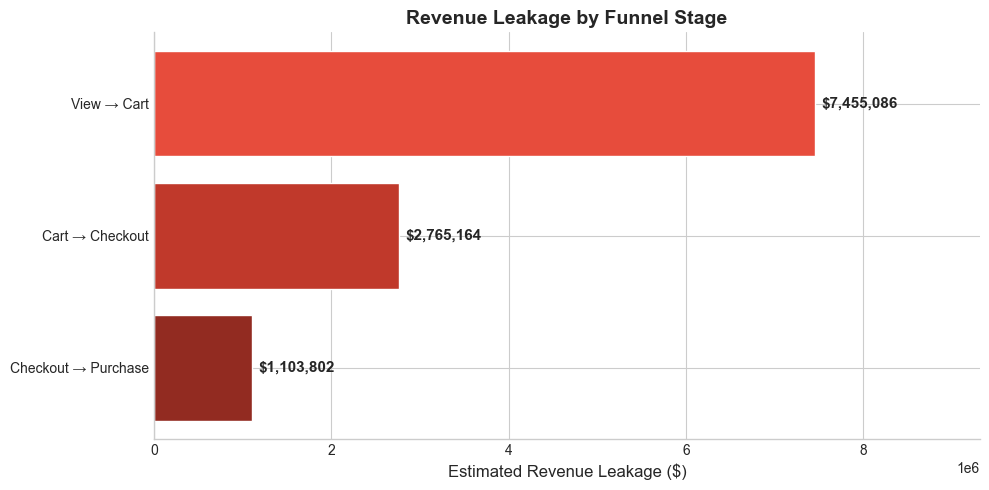

In [16]:
# Plot 2: Revenue Leakage by Funnel Stage
fig, ax = plt.subplots(figsize=(10, 5))

stage_names = leakage_df['funnel_stage'].tolist()
leakage_values = leakage_df['estimated_revenue_leakage'].tolist()

bars = ax.barh(stage_names, leakage_values, color=['#e74c3c', '#c0392b', '#922b21'], edgecolor='white')

# Add value labels
for bar, val in zip(bars, leakage_values):
    ax.text(val + max(leakage_values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'${val:,.0f}', ha='left', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Estimated Revenue Leakage ($)', fontsize=12)
ax.set_title('Revenue Leakage by Funnel Stage', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(leakage_values) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

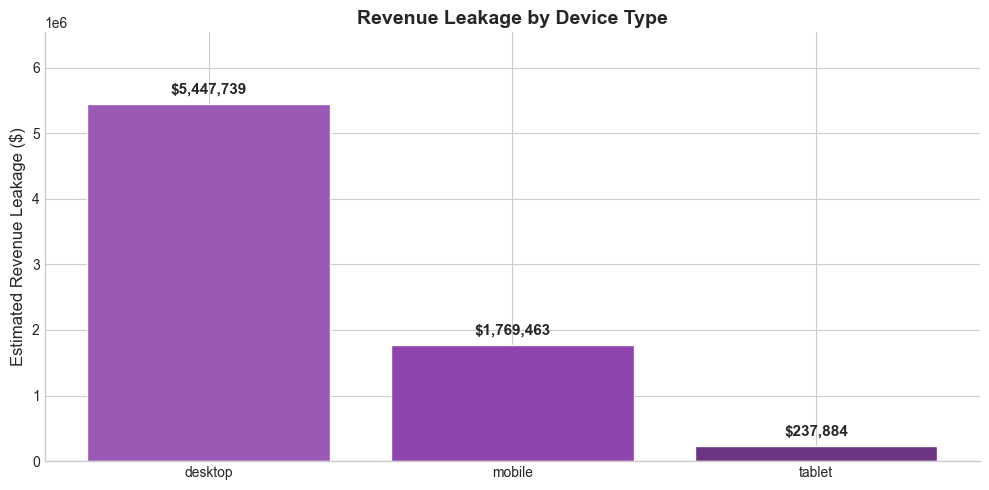

In [17]:
# Plot 3: Revenue Leakage by Device Type
fig, ax = plt.subplots(figsize=(10, 5))

device_names = device_leakage['device_type'].tolist()
device_leakage_values = device_leakage['estimated_leakage'].tolist()

bars = ax.bar(device_names, device_leakage_values, color=['#9b59b6', '#8e44ad', '#6c3483'], edgecolor='white')

# Add value labels
for bar, val in zip(bars, device_leakage_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(device_leakage_values)*0.02, 
            f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Estimated Revenue Leakage ($)', fontsize=12)
ax.set_title('Revenue Leakage by Device Type', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(device_leakage_values) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 8️⃣ Export Dashboard-Ready Tables

In [18]:
def export_dashboard_tables(df: pd.DataFrame, output_dir: str):
    """
    Export aggregated, dashboard-ready CSVs for Tableau.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Funnel Summary
    funnel_metrics = compute_funnel_metrics(df)
    revenue_metrics = compute_revenue_metrics(df)
    
    funnel_summary = pd.DataFrame([{
        'total_sessions': funnel_metrics['total_sessions'],
        'viewed_product': funnel_metrics['viewed_product'],
        'added_to_cart': funnel_metrics['added_to_cart'],
        'checkout_started': funnel_metrics['checkout_started'],
        'purchased': funnel_metrics['purchased'],
        'view_to_cart_rate': funnel_metrics['view_to_cart_rate'],
        'cart_to_checkout_rate': funnel_metrics['cart_to_checkout_rate'],
        'checkout_to_purchase_rate': funnel_metrics['checkout_to_purchase_rate'],
        'overall_conversion_rate': funnel_metrics['overall_conversion_rate'],
        'total_revenue': revenue_metrics['total_revenue'],
        'average_order_value': revenue_metrics['average_order_value'],
        'revenue_per_session': revenue_metrics['revenue_per_session']
    }])
    funnel_summary.to_csv(os.path.join(output_dir, 'funnel_summary.csv'), index=False)
    print(f"✓ Exported funnel_summary.csv")
    
    # 2. Revenue Leakage by Stage
    leakage_by_stage = compute_revenue_leakage_by_stage(df)
    leakage_by_stage.to_csv(os.path.join(output_dir, 'revenue_leakage_by_stage.csv'), index=False)
    print(f"✓ Exported revenue_leakage_by_stage.csv")
    
    # 3. Device Leakage
    device_seg = compute_segment_leakage(df, 'device_type')
    device_seg.to_csv(os.path.join(output_dir, 'device_leakage.csv'), index=False)
    print(f"✓ Exported device_leakage.csv")
    
    # 4. Traffic Source Leakage
    traffic_seg = compute_segment_leakage(df, 'traffic_source')
    traffic_seg.to_csv(os.path.join(output_dir, 'traffic_source_leakage.csv'), index=False)
    print(f"✓ Exported traffic_source_leakage.csv")
    
    print(f"\n✓ All dashboard tables exported to: {output_dir}")

In [19]:
# Export to Tableau_Outputs
OUTPUT_DIR = '../Outputs/Tableau_Outputs'
export_dashboard_tables(df, OUTPUT_DIR)

✓ Exported funnel_summary.csv
✓ Exported revenue_leakage_by_stage.csv
✓ Exported device_leakage.csv
✓ Exported traffic_source_leakage.csv

✓ All dashboard tables exported to: ../Outputs/Tableau_Outputs


In [20]:
# Verify exports
print("\nExported files:")
for f in os.listdir(OUTPUT_DIR):
    if f.endswith('.csv'):
        filepath = os.path.join(OUTPUT_DIR, f)
        size = os.path.getsize(filepath)
        print(f"  {f}: {size:,} bytes")


Exported files:
  device_leakage.csv: 453 bytes
  funnel_summary.csv: 368 bytes
  revenue_leakage_by_stage.csv: 256 bytes
  traffic_source_leakage.csv: 8,164 bytes


---

**End of Notebook**

All metrics validated and dashboard-ready tables exported to `Tableau_Outputs/`.

In [22]:

funnel_stages = pd.DataFrame({
    "stage": [
        "Viewed Product",
        "Added To Cart",
        "Checkout Started",
        "Purchased"
    ],
    "sessions": [
        metrics["viewed_product"],
        metrics["added_to_cart"],
        metrics["checkout_started"],
        metrics["purchased"]
    ],
    "conversion_rate": [
        100.0,  # View stage is baseline 100%
        metrics["view_to_cart_rate"],
        metrics["cart_to_checkout_rate"],
        metrics["checkout_to_purchase_rate"]
    ]
})

funnel_stages.to_csv("../Outputs/Tableau_Outputs/funnel_stages.csv", index=False)